In [1]:
import pandas as pd

print("Project Environment is Ready!!")

Project Environment is Ready!!


In [2]:
from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions", "simplified")


In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [4]:
print(dataset["train"][0])

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


In [5]:
label_names = dataset["train"].features["labels"].feature.names
print(label_names)



['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [6]:
example = dataset["train"][0]

print("Text:", example["text"])
print("label numbers:", example["labels"])
print("Emotions:", [label_names[i] for i in example ["labels"]])

Text: My favourite food is anything I didn't have to cook myself.
label numbers: [27]
Emotions: ['neutral']


In [7]:
# Counting the number of single-label and multiple-label examples in the training dataset

single_label = 0
multiple_label = 0

for example in dataset["train"]:
    if len(example["labels"])==1:
        single_label += 1
    else:
        multiple_label += 1

print("Single label examples:", single_label)
print("Multiple label examples:", multiple_label)

Single label examples: 36308
Multiple label examples: 7102


In [8]:
# Displaying the first example with multiple emotions in the training dataset

for example in dataset["train"]:
    if len(example["labels"])>1:
        print("Text:", example["text"])
        print("label numbers:", example["labels"])
        print("Emotions:", [label_names[i] for i in example ["labels"]])
        break

Text: We need more boards and to create a bit more space for [NAME]. Then we’ll be good.
label numbers: [8, 20]
Emotions: ['desire', 'optimism']


In [9]:
#Counting the number of examples for each emotion in the training dataset

from collections import Counter

emotion_counts= Counter()

for example in dataset["train"]:
    for label in example["labels"]:
        emotion_counts[label_names[label]]+=1\

print(emotion_counts)

Counter({'neutral': 14219, 'admiration': 4130, 'approval': 2939, 'gratitude': 2662, 'annoyance': 2470, 'amusement': 2328, 'curiosity': 2191, 'love': 2086, 'disapproval': 2022, 'optimism': 1581, 'anger': 1567, 'joy': 1452, 'confusion': 1368, 'sadness': 1326, 'disappointment': 1269, 'realization': 1110, 'caring': 1087, 'surprise': 1060, 'excitement': 853, 'disgust': 793, 'desire': 641, 'fear': 596, 'remorse': 545, 'embarrassment': 303, 'nervousness': 164, 'relief': 153, 'pride': 111, 'grief': 77})


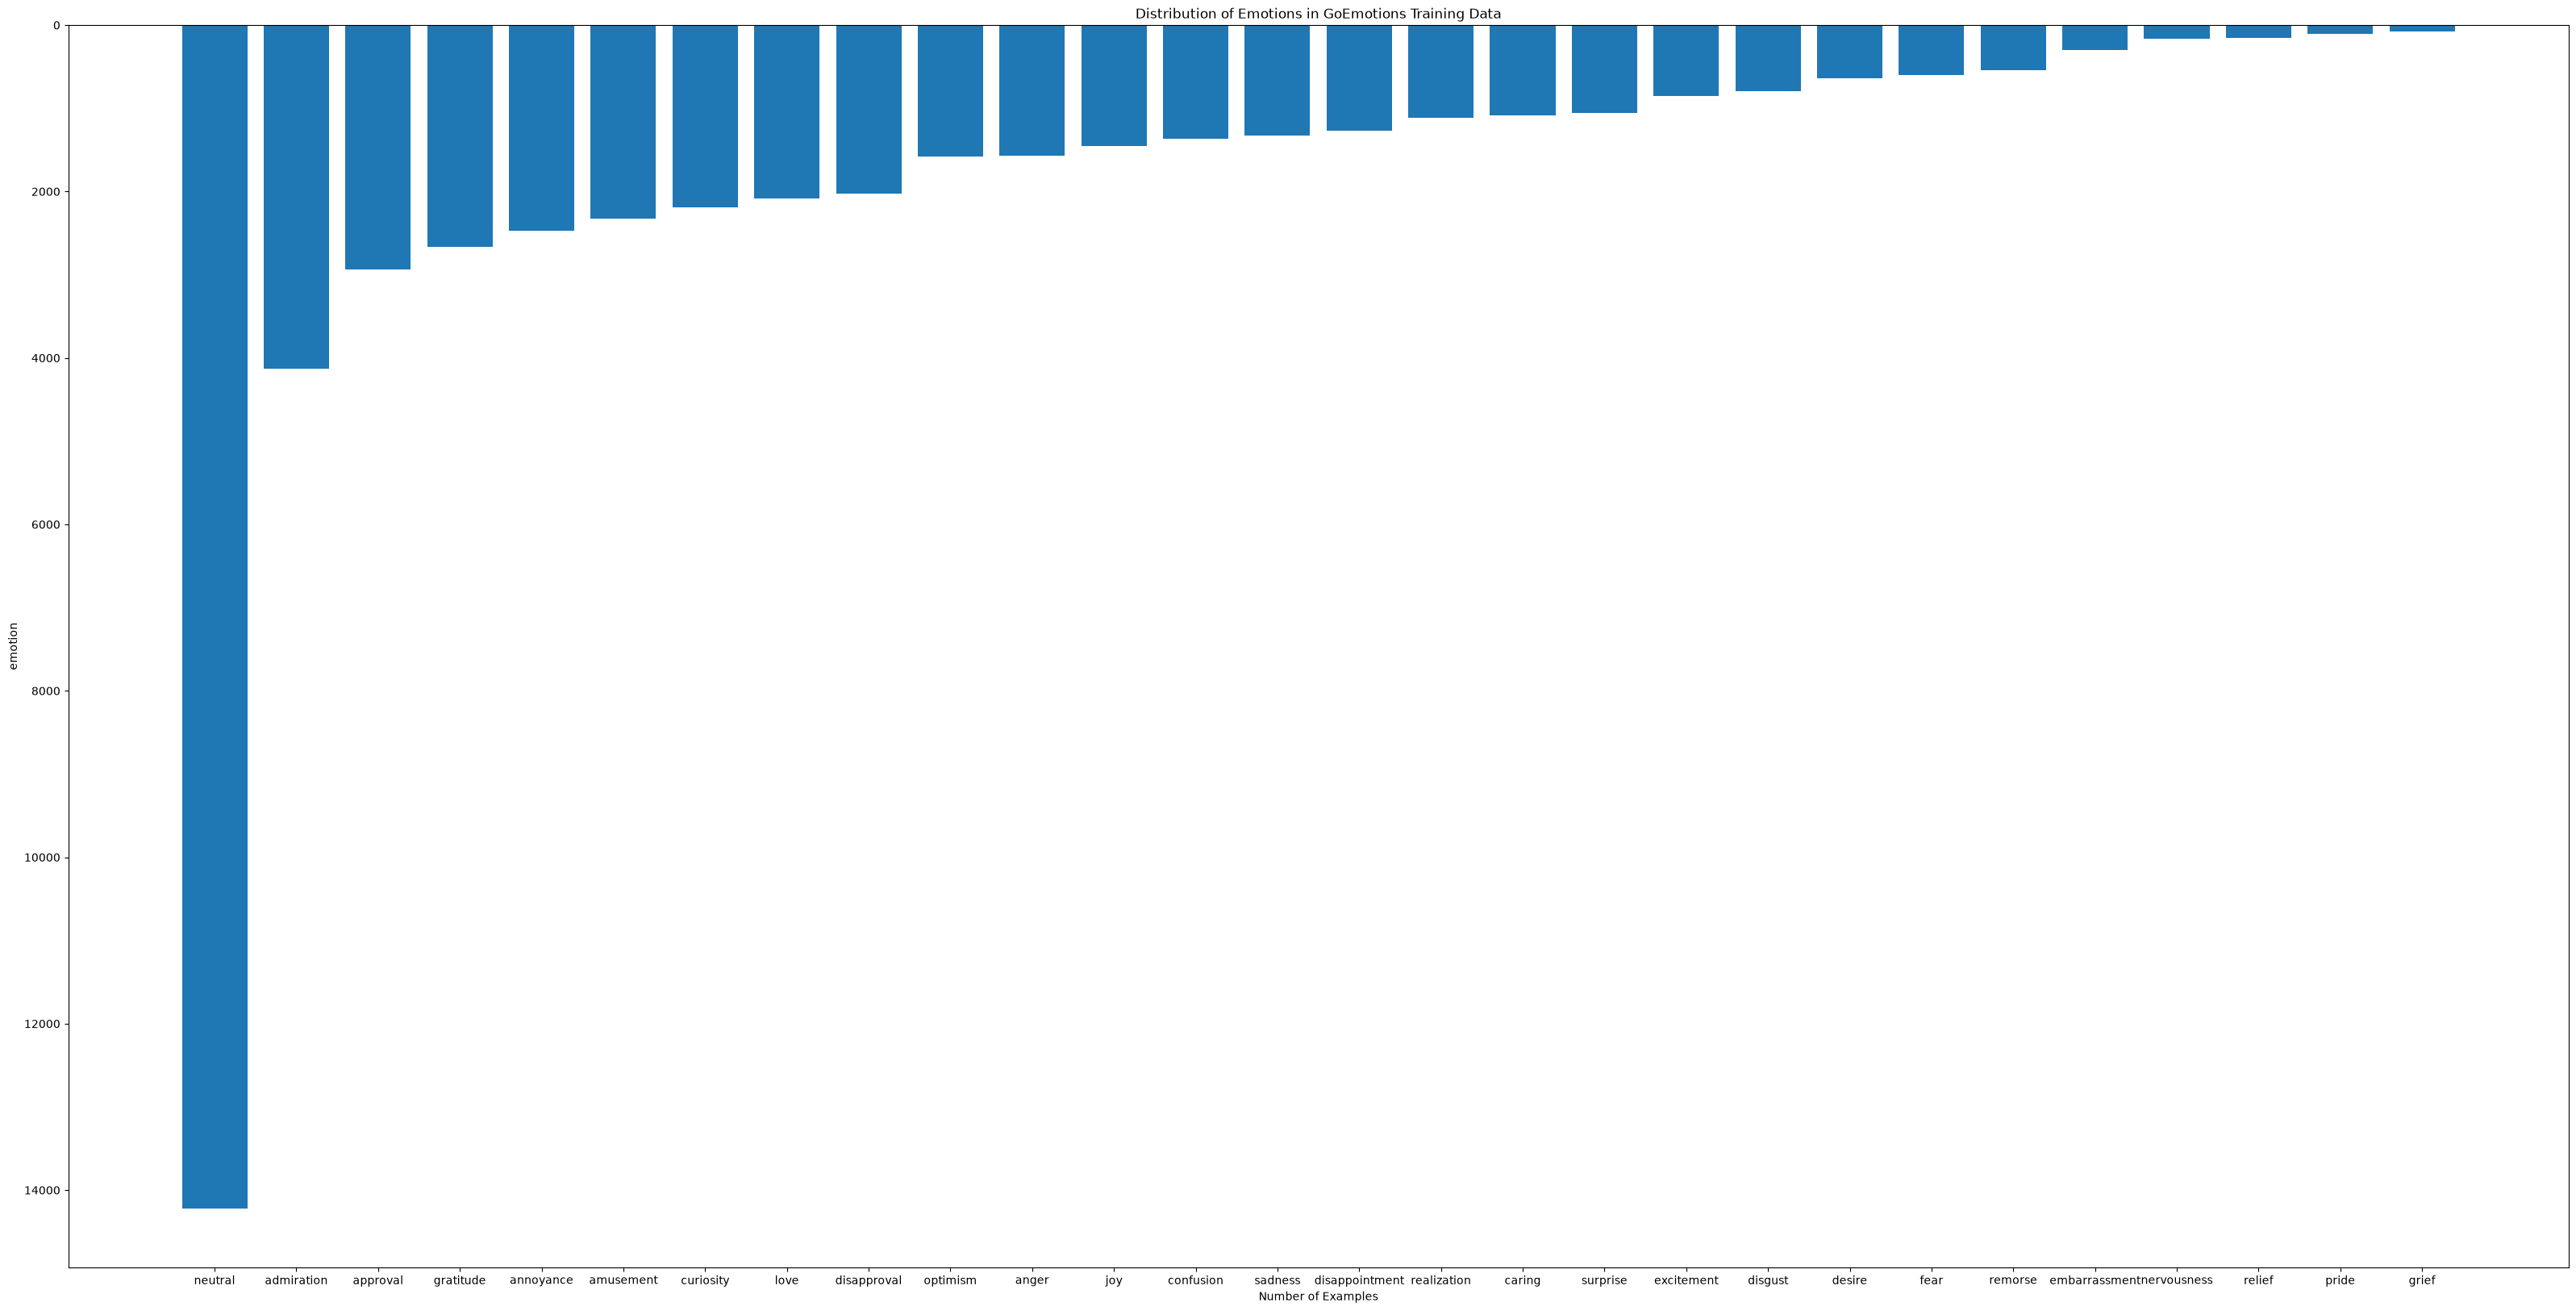

In [10]:
# Distribution of Emotions in GoEmotions Training Data

import matplotlib.pyplot as plt

sorted_counted = emotion_counts.most_common()

emotions = [item[0] for item in sorted_counted]
counts = [item[1] for item in sorted_counted]

plt.figure(figsize= (40,20))
plt.bar(emotions, counts)

plt.xlabel("Number of Examples")
plt.ylabel("emotion")
plt.title("Distribution of Emotions in GoEmotions Training Data")

plt.gca().invert_yaxis()

plt.show()

In [11]:
# Length of words in training dataset

text_lengths = []

for example in dataset["train"]:
    text_lengths.append(len(example["text"].split()))


print("Shortest Text:", min(text_lengths), "words")
print("Longest Text:", max(text_lengths), "words")
print("Average Text Length:", sum(text_lengths)/len(text_lengths), "words")

Shortest Text: 1 words
Longest Text: 33 words
Average Text Length: 12.840175074867542 words


In [12]:
#Checking missing text and missing labels


missing_text = 0
missing_labels = 0

for example in dataset["train"]:
    if not example["text"].strip():
        missing_text+=1

    if len(example["labels"])== 0:
        missing_labels +=1

print("Missing text examples:", missing_text)
print("Missing label examples:", missing_labels)

Missing text examples: 0
Missing label examples: 0


In [13]:
# Count duplicate texts in the training dataset

texts = [example["text"] for example in dataset["train"]]

duplicate_count= len(texts) - len(set(texts))

print("Duplicate Texts:", duplicate_count)         

Duplicate Texts: 183


In [14]:
# Encode the labels using MultiLabelBinarizer

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes= range(len(label_names)))

y_train = mlb.fit_transform(dataset["train"]["labels"])

print("Original Labels:", dataset["train"][0]["labels"])
print("Encoded Labels:", y_train[0])



Original Labels: [27]
Encoded Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [15]:
# Extract training texts from the dataset

X_train = dataset["train"]["text"]

print("Number of Training Texts:", len(X_train))
print("First Training Texts:", X_train[0])

Number of Training Texts: 43410
First Training Texts: My favourite food is anything I didn't have to cook myself.


In [16]:
# Load and transform the training texts using TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [17]:
# Transform the Training Text

X_train_tfidf = tfidf.fit_transform(X_train)

print("Original Shape:", len(X_train))
print("TF-IDF shape:", X_train_tfidf.shape)

Original Shape: 43410
TF-IDF shape: (43410, 26379)


In [18]:
#Importing LogisticRegression and OneVsRestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

model = OneVsRestClassifier(LogisticRegression(max_iter=1000))


In [19]:
# Training Logistic Regression

model.fit(X_train_tfidf,y_train)

print("Model Training Completed!!")

Model Training Completed!!


In [20]:
#Validating data

X_val = dataset["validation"]["text"]

X_val_tfidf = tfidf.transform(X_val)
y_val = mlb.transform(dataset["validation"]["labels"])

print("Validation examples:", len(X_val))

Validation examples: 5426


In [21]:
#Prediction on validation data

y_pred = model.predict(X_val_tfidf)

print("Predictions on validation data completed!!")
print("Predictions Shape:", y_pred.shape)

Predictions on validation data completed!!
Predictions Shape: (5426, 28)


In [22]:
# calculating precision, recall, and F1 score on validation data

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, y_pred, average='micro')
recall = recall_score(y_val, y_pred, average='micro')
f1 = f1_score(y_val, y_pred, average='micro')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7106463878326996
Recall: 0.2929467084639498
F1 Score: 0.4148723640399556


In [23]:
from sklearn.metrics import  classification_report

print(classification_report(y_val, y_pred, target_names= label_names, zero_division=0))


                precision    recall  f1-score   support

    admiration       0.81      0.40      0.54       488
     amusement       0.80      0.49      0.61       303
         anger       0.65      0.15      0.25       195
     annoyance       0.36      0.01      0.03       303
      approval       0.68      0.05      0.10       397
        caring       0.64      0.05      0.09       153
     confusion       0.44      0.05      0.09       152
     curiosity       0.63      0.11      0.19       248
        desire       0.80      0.21      0.33        77
disappointment       0.00      0.00      0.00       163
   disapproval       0.35      0.02      0.04       292
       disgust       0.64      0.07      0.13        97
 embarrassment       0.67      0.06      0.11        35
    excitement       0.38      0.05      0.09        96
          fear       0.88      0.16      0.26        90
     gratitude       0.97      0.81      0.88       358
         grief       0.00      0.00      0.00  

In [24]:
shown = 0

for i in range(len(X_val)):
    actual = [label_names[j]  for j in range(len(label_names)) if y_val[i][j]==1]
    predicted = [label_names[j]  for j in range(len(label_names)) if y_pred[i][j]==1]

    if actual != predicted:
        print("Text:", X_val[i])
        print("Actual Emotion:", actual)
        print("Predicted Emotion:", predicted)
        print("-------------")

        shown+=1

        if shown == 5:
            break


Text: Is this in New Orleans?? I really feel like this is New Orleans.
Actual Emotion: ['neutral']
Predicted Emotion: []
-------------
Text: You know the answer man, you are programmed to capture those codes they send you, don’t avoid them!
Actual Emotion: ['approval', 'neutral']
Predicted Emotion: ['neutral']
-------------
Text: The economy is heavily controlled and subsidized by the government. In any case, I was poking at the lack of nuance in US politics today
Actual Emotion: ['approval', 'neutral']
Predicted Emotion: ['neutral']
-------------
Text: He could have easily taken a real camera from a legitimate source and change the price in Word/Photoshop and then print it out.
Actual Emotion: ['optimism']
Predicted Emotion: ['neutral']
-------------
Text: Wah Mum other people call me on my bullshit and I can't ban them , Go out side son.
Actual Emotion: ['anger']
Predicted Emotion: []
-------------


In [25]:
# Training baseline model with LinearSVC

from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

svm_model = OneVsRestClassifier(LinearSVC())

In [26]:
svm_model.fit(X_train_tfidf, y_train)

print("SVM Training Completed!!")

SVM Training Completed!!


In [27]:
#SVM Predictions

svm_pred = svm_model.predict(X_val_tfidf)

print("SVM Predictions Completed!!")

SVM Predictions Completed!!


In [28]:
# caluculating Precison, Recall and F1 score

svm_precision = precision_score(y_val, svm_pred, average = "micro")
svm_recall = recall_score(y_val,svm_pred, average = "micro")
svm_f1 = f1_score(y_val, svm_pred, average = "micro")

print("SVM Precision: ", svm_precision)
print("SVM Recall: ", svm_recall)
print("SVM F1 Score: ", svm_f1)

SVM Precision:  0.6685196021064951
SVM Recall:  0.35815047021943575
SVM F1 Score:  0.4664217187181057


In [29]:
# Generating per emotion Report

print(classification_report(y_val,svm_pred,target_names=label_names,zero_division=0))


                precision    recall  f1-score   support

    admiration       0.76      0.48      0.59       488
     amusement       0.79      0.60      0.68       303
         anger       0.60      0.22      0.32       195
     annoyance       0.40      0.06      0.10       303
      approval       0.59      0.08      0.14       397
        caring       0.52      0.08      0.15       153
     confusion       0.69      0.13      0.22       152
     curiosity       0.67      0.14      0.23       248
        desire       0.72      0.30      0.42        77
disappointment       0.22      0.01      0.02       163
   disapproval       0.36      0.04      0.07       292
       disgust       0.66      0.26      0.37        97
 embarrassment       0.89      0.23      0.36        35
    excitement       0.53      0.10      0.17        96
          fear       0.78      0.40      0.53        90
     gratitude       0.96      0.86      0.91       358
         grief       0.00      0.00      0.00  

In [30]:
import sys

print(sys.version)


3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [31]:
import torch
print("PyTorch version:", torch.__version__)
print("Pytorch is working!!")

PyTorch version: 2.14.0+cpu
Pytorch is working!!


In [32]:
import torch

print("CUDA available:", torch.cuda.is_available())

CUDA available: False


In [33]:
import transformers

print("Transformers Version:", transformers.__version__)
print("Trannsformers is working!!")


Transformers Version: 5.17.0
Trannsformers is working!!


In [35]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizer Loaded")

Tokenizer Loaded


In [36]:
sample_text = "The first 30 minutes of the movie paradise were straight ass"

tokens = tokenizer.tokenize(sample_text)

print(tokens)

['the', 'first', '30', 'minutes', 'of', 'the', 'movie', 'paradise', 'were', 'straight', 'ass']


In [37]:
encoded = tokenizer(sample_text)

print(encoded)

{'input_ids': [101, 1996, 2034, 2382, 2781, 1997, 1996, 3185, 9097, 2020, 3442, 4632, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [38]:
# load DistilBERT for emotion classification

from transformers import AutoModelForSequenceClassification

num_labels = len(label_names)

distilbert_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", 
                                                                      num_labels=num_labels, 
                                                                      problem_type = "multi_label_classification")
print("DistilBERT Model Loaded for Emotion Classification") 
print("Number of emotion labels:", num_labels)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Model Loaded for Emotion Classification
Number of emotion labels: 28


In [39]:
example_labels = dataset["train"][0]["labels"]

label_vector = [0.0]*len(label_names)

for label in example_labels:
    label_vector[label] = 1.0

print("Original labels:", example_labels)
print("multi-hot labels:", label_vector)

Original labels: [27]
multi-hot labels: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]


In [40]:
print("length:", len(label_vector))
print("last value:", label_vector[27])
print("emotion:", label_names[27])

length: 28
last value: 1.0
emotion: neutral


In [41]:
def preprocess(example):

    # convert the text into DistilBERT tokens/numbers
    encoded = tokenizer(
        example["text"],
                truncation= True,
                max_length=64
    )

    #create 28 zeros
    label_vector =[0.0]*len(label_names)

    #change the correct emotion positions to 1
    for label in example["labels"]:
        label_vector[label]=1.0

    encoded["labels"]= label_vector

    return encoded



In [42]:
transformers_dataset = dataset.map(preprocess)



In [43]:
print(transformers_dataset["train"][0])

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], 'id': 'eebbqej', 'input_ids': [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134, 1005, 1056, 2031, 2000, 5660, 2870, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [44]:
import torch

print("CPU threads available:", torch.get_num_threads())

CPU threads available: 8


In [45]:
small_train = transformers_dataset["train"].shuffle(seed=42).select(range(2000))

print("Training examples:", len(small_train))

Training examples: 2000


In [46]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir = "./distibutert_results",
    num_train_epochs = 1,
    per_device_train_batch_size = 8,
    learning_rate= 5e-5,
    logging_steps = 50,
    save_strategy="no",
    report_to="none"
)
print("Training settings ready!!")

Training settings ready!!


In [47]:
# create thr trainer

from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model = distilbert_model,
    args = training_args,
    train_dataset= small_train,
    data_collator=data_collator
)

print("Trainer Ready")

Trainer Ready


In [48]:
print("Training examples:",len(trainer.train_dataset))
print("Device:", trainer.args.device)

Training examples: 2000
Device: cpu


In [49]:
from datasets import Sequence, Value

transformers_dataset = transformers_dataset.cast_column("labels", Sequence(Value("float32")))

small_train = transformers_dataset["train"].shuffle(seed=42).select(range(2000))

print(transformers_dataset["train"].features["labels"])

List(Value('float32'))


In [80]:
from transformers import AutoModelForSequenceClassification

final_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names),
    problem_type="multi_label_classification"
)

print("Fresh DistilBERT model ready!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh DistilBERT model ready!


In [81]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Data collator ready!")

Data collator ready!


In [82]:
full_train = transformers_dataset["train"]

print("Training examples:", len(full_train))

Training examples: 43410


In [83]:
from transformers import TrainingArguments

final_training_args = TrainingArguments(
    output_dir="./final_distilbert_results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    logging_steps=500,
    save_strategy="no",
    report_to="none"
)

print("Training settings ready!")


Training settings ready!


In [84]:
num_train_epochs=1

In [85]:
from transformers import Trainer

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=full_train,
    data_collator=data_collator
)

print("Final Trainer ready!")

Final Trainer ready!


In [86]:
final_trainer.train()

c:\Users\devih\OneDrive\Desktop\emotion_intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.167696
1000,0.113800
1500,0.101769
2000,0.097083
2500,0.093378
3000,0.093911
3500,0.091367
4000,0.086349
4500,0.087240
5000,0.088386


TrainOutput(global_step=5427, training_loss=0.10071055586438647, metrics={'train_runtime': 1936.788, 'train_samples_per_second': 22.413, 'train_steps_per_second': 2.802, 'total_flos': 356125647570048.0, 'train_loss': 0.10071055586438647, 'epoch': 1.0})

In [87]:
final_model.config.id2label = {
    i: label for i, label in enumerate(label_names)
}

final_model.config.label2id = {
    label: i for i, label in enumerate(label_names)
}

final_model.config.problem_type = "multi_label_classification"

final_model.save_pretrained("./final_emotion_model")
tokenizer.save_pretrained("./final_emotion_model")

print("FINAL TRAINED MODEL SAVED!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FINAL TRAINED MODEL SAVED!


In [88]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

saved_model = AutoModelForSequenceClassification.from_pretrained(
    "./final_emotion_model"
)

saved_tokenizer = AutoTokenizer.from_pretrained(
    "./final_emotion_model"
)

print("Saved trained model loaded successfully!")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Saved trained model loaded successfully!


In [98]:
import torch

test_text = "I hate sleeping early"

inputs = saved_tokenizer(
    test_text,
    return_tensors="pt",
    truncation=True,
    max_length=64
)

saved_model.eval()

with torch.no_grad():
    outputs = saved_model(**inputs)

probabilities = torch.sigmoid(outputs.logits)[0]

results = []

for i, probability in enumerate(probabilities):
    if probability >= 0.30:
        results.append(
            (label_names[i], round(float(probability), 3))
        )

results.sort(key=lambda x: x[1], reverse=True)

print(results)

[('anger', 0.743)]


In [92]:
from transformers import Trainer

validation_trainer = Trainer(
    model=saved_model,
    data_collator=data_collator
)

validation_output = validation_trainer.predict(
    transformers_dataset["validation"]
)

validation_logits = validation_output.predictions

validation_probabilities = torch.sigmoid(
    torch.tensor(validation_logits)
).numpy()

print("Validation predictions ready!")
print("Shape:", validation_probabilities.shape)

c:\Users\devih\OneDrive\Desktop\emotion_intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation predictions ready!
Shape: (5426, 28)


In [93]:
from sklearn.metrics import f1_score

y_val = mlb.transform(dataset["validation"]["labels"])

test_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for t in test_values:
    temp_pred = (validation_probabilities >= t).astype(int)

    micro = f1_score(
        y_val,
        temp_pred,
        average="micro",
        zero_division=0
    )

    macro = f1_score(
        y_val,
        temp_pred,
        average="macro",
        zero_division=0
    )

    print(
        "Threshold:", t,
        "| Micro F1:", round(micro, 4),
        "| Macro F1:", round(macro, 4)
    )
    

Threshold: 0.1 | Micro F1: 0.5372 | Macro F1: 0.4511
Threshold: 0.15 | Micro F1: 0.5744 | Macro F1: 0.4521
Threshold: 0.2 | Micro F1: 0.5984 | Macro F1: 0.4644
Threshold: 0.25 | Micro F1: 0.6085 | Macro F1: 0.4623
Threshold: 0.3 | Micro F1: 0.6109 | Macro F1: 0.454
Threshold: 0.35 | Micro F1: 0.6039 | Macro F1: 0.4372
Threshold: 0.4 | Micro F1: 0.5927 | Macro F1: 0.422
Threshold: 0.45 | Micro F1: 0.5791 | Macro F1: 0.403
Threshold: 0.5 | Micro F1: 0.5619 | Macro F1: 0.3756


In [94]:
BEST_THRESHOLD = 0.30

print("Selected validation threshold:", BEST_THRESHOLD)

Selected validation threshold: 0.3


In [95]:
test_output = validation_trainer.predict(
    transformers_dataset["test"]
)

test_logits = test_output.predictions

test_probabilities = torch.sigmoid(
    torch.tensor(test_logits)
).numpy()

y_test = mlb.transform(dataset["test"]["labels"])

test_pred = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

print("Test predictions ready!")
print("Predictions shape:", test_pred.shape)
print("Labels shape:", y_test.shape)

c:\Users\devih\OneDrive\Desktop\emotion_intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test predictions ready!
Predictions shape: (5427, 28)
Labels shape: (5427, 28)


In [96]:
from sklearn.metrics import precision_score, recall_score, f1_score

test_precision = precision_score(
    y_test, test_pred, average="micro", zero_division=0
)

test_recall = recall_score(
    y_test, test_pred, average="micro", zero_division=0
)

test_micro_f1 = f1_score(
    y_test, test_pred, average="micro", zero_division=0
)

test_macro_f1 = f1_score(
    y_test, test_pred, average="macro", zero_division=0
)

print("FINAL TEST RESULTS")
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("Micro F1:", round(test_micro_f1, 4))
print("Macro F1:", round(test_macro_f1, 4))

FINAL TEST RESULTS
Precision: 0.6051
Recall: 0.6268
Micro F1: 0.6158
Macro F1: 0.4505


In [97]:
def predict_emotion(text):
    inputs = saved_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=64
    )

    saved_model.eval()

    with torch.no_grad():
        outputs = saved_model(**inputs)

    probabilities = torch.sigmoid(outputs.logits)[0].numpy()

    predictions = []

    for i, probability in enumerate(probabilities):
        if probability >= BEST_THRESHOLD:
            predictions.append(
                (label_names[i], round(float(probability), 3))
            )

    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions

In [100]:
predict_emotion("The movie's CGI content hideous")

[('disgust', 0.688)]

In [101]:
predict_emotion("I heard of a threatening voice on the phone so I am reluctant to pick up more calls")

[]

In [102]:
predict_emotion("Laterns is a strong come back for DC")

[('neutral', 0.464), ('admiration', 0.322)]

In [105]:
predict_emotion("The paradise movie didn't live up to my expectations")

[('disapproval', 0.338)]

In [106]:
predict_emotion("What are you thoughts on the new Batman movie?")

[('curiosity', 0.617), ('neutral', 0.343)]

In [107]:
predict_emotion("GET TO THE CHOPPER!")

[('neutral', 0.641)]

In [109]:
predict_emotion("I am looking forward to the next dune movie")

[('neutral', 0.445)]

In [110]:
predict_emotion("Kimi Antonelli's performance is surprisingly dominant")

[('admiration', 0.639)]

In [111]:
predict_emotion("It sucks that I dropped my cookie on the floor because I really wanted to eat it")

[]

In [112]:
predict_emotion("The ending of lala land is depressing")

[('sadness', 0.738), ('disappointment', 0.306)]

In [113]:
def predict_logistic(text):
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)[0]

    return [
        label_names[i]
        for i in range(len(label_names))
        if prediction[i] == 1
    ]


def predict_svm(text):
    text_tfidf = tfidf.transform([text])
    prediction = svm_model.predict(text_tfidf)[0]

    return [
        label_names[i]
        for i in range(len(label_names))
        if prediction[i] == 1
    ]

print("Traditional model prediction functions ready!")

Traditional model prediction functions ready!


In [116]:
comparison_examples = [
    "The movie's CGI content hideous",
    "I heard of a threatening voice on the phone so I am reluctant to pick up more calls",
    "Lanterns is a strong come back for DC",
    "The paradise movie didn't live up to my expectations",
    "What are you thoughts on the new Batman movie?",
    "GET TO THE CHOPPER!",
    "I am looking forward to the next dune movie",
    "Kimi Antonelli's performance is surprisingly dominant",
    "It sucks that I dropped my cookie on the floor because I really wanted to eat it",
    "The ending of lala land is depressing"
]

In [117]:
for text in comparison_examples:
    print("\nTEXT:", text)
    print("LR:", predict_logistic(text),
          "| SVM:", predict_svm(text),
          "| DistilBERT:", predict_emotion(text))


TEXT: The movie's CGI content hideous
LR: [] | SVM: [] | DistilBERT: [('disgust', 0.688)]

TEXT: I heard of a threatening voice on the phone so I am reluctant to pick up more calls
LR: [] | SVM: [] | DistilBERT: []

TEXT: Lanterns is a strong come back for DC
LR: [] | SVM: ['neutral'] | DistilBERT: [('neutral', 0.467), ('admiration', 0.303)]

TEXT: The paradise movie didn't live up to my expectations
LR: [] | SVM: [] | DistilBERT: [('disapproval', 0.338)]

TEXT: What are you thoughts on the new Batman movie?
LR: [] | SVM: [] | DistilBERT: [('curiosity', 0.617), ('neutral', 0.343)]

TEXT: GET TO THE CHOPPER!
LR: [] | SVM: ['neutral'] | DistilBERT: [('neutral', 0.641)]

TEXT: I am looking forward to the next dune movie
LR: [] | SVM: [] | DistilBERT: [('neutral', 0.445)]

TEXT: Kimi Antonelli's performance is surprisingly dominant
LR: [] | SVM: ['surprise'] | DistilBERT: [('admiration', 0.639)]

TEXT: It sucks that I dropped my cookie on the floor because I really wanted to eat it
LR: []

In [118]:
X_test = dataset["test"]["text"]
X_test_tfidf = tfidf.transform(X_test)

lr_test_pred = model.predict(X_test_tfidf)
svm_test_pred = svm_model.predict(X_test_tfidf)

print("Logistic Regression and SVM test predictions ready!")

Logistic Regression and SVM test predictions ready!


In [119]:
def show_test_metrics(name, predictions):
    precision = precision_score(
        y_test, predictions, average="micro", zero_division=0
    )

    recall = recall_score(
        y_test, predictions, average="micro", zero_division=0
    )

    micro_f1 = f1_score(
        y_test, predictions, average="micro", zero_division=0
    )

    macro_f1 = f1_score(
        y_test, predictions, average="macro", zero_division=0
    )

    print(name)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("Micro F1:", round(micro_f1, 4))
    print("Macro F1:", round(macro_f1, 4))
    print()


show_test_metrics("Logistic Regression", lr_test_pred)
show_test_metrics("Linear SVM", svm_test_pred)
show_test_metrics("DistilBERT", test_pred)

Logistic Regression
Precision: 0.7113
Recall: 0.2963
Micro F1: 0.4183
Macro F1: 0.2366

Linear SVM
Precision: 0.6691
Recall: 0.3664
Micro F1: 0.4735
Macro F1: 0.3379

DistilBERT
Precision: 0.6051
Recall: 0.6268
Micro F1: 0.6158
Macro F1: 0.4505



In [120]:
import os

print("Model folder exists:",
      os.path.exists("./final_emotion_model"))

print("Files:",
      os.listdir("./final_emotion_model"))

Model folder exists: True
Files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [121]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "DistilBERT"
    ],
    "Precision": [
        0.7113,
        0.6691,
        0.6051
    ],
    "Recall": [
        0.2963,
        0.3664,
        0.6268
    ],
    "Micro F1": [
        0.4183,
        0.4735,
        0.6158
    ],
    "Macro F1": [
        0.2366,
        0.3379,
        0.4505
    ]
})

results_df

,Model,Precision,Recall,Micro F1,Macro F1
0,Logistic Regression,0.7113,0.2963,0.4183,0.2366
1,Linear SVM,0.6691,0.3664,0.4735,0.3379
2,DistilBERT,0.6051,0.6268,0.6158,0.4505
